In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
df =pd.read_csv("Bank_Marketing_Campaign.csv")
df

,id,customer_age,job_type,marital,education,default,balance,housing_loan,personal_loan,communication_type,day_of_month,month,last_contact_duration,num_contacts_in_campaign,days_since_prev_campaign_contact,num_contacts_prev_campaign,prev_campaign_outcome,term_deposit_subscribed
0,id_43823,28.0,management,single,tertiary,no,285.0,yes,no,unknown,26,jun,303.0,4.0,NaN,0,unknown,0
1,id_32289,34.0,blue-collar,married,secondary,no,934.0,no,yes,cellular,18,nov,143.0,2.0,132.0,1,other,0
2,id_10523,46.0,technician,married,secondary,no,656.0,no,no,cellular,5,feb,101.0,4.0,NaN,0,unknown,0
3,id_43951,34.0,services,single,secondary,no,2.0,yes,no,unknown,20,may,127.0,3.0,NaN,0,unknown,0
4,id_40992,41.0,blue-collar,married,primary,no,1352.0,yes,no,cellular,13,may,49.0,2.0,NaN,0,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31642,id_27290,58.0,admin.,married,secondary,no,567.0,yes,no,cellular,2,feb,99.0,2.0,265.0,3,other,0
31643,id_20428,51.0,management,married,tertiary,no,1072.0,no,no,unknown,20,jun,31.0,7.0,NaN,0,unknown,0
31644,id_44679,41.0,unemployed,married,primary,no,242.0,yes,no,unknown,23,may,89.0,2.0,NaN,0,unknown,0
31645,id_4841,48.0,services,married,secondary,no,2699.0,no,no,cellular,11,aug,216.0,6.0,NaN,0,unknown,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31647 entries, 0 to 31646
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                31647 non-null  object 
 1   customer_age                      31028 non-null  float64
 2   job_type                          31647 non-null  object 
 3   marital                           31497 non-null  object 
 4   education                         31647 non-null  object 
 5   default                           31647 non-null  object 
 6   balance                           31248 non-null  float64
 7   housing_loan                      31647 non-null  object 
 8   personal_loan                     31498 non-null  object 
 9   communication_type                31647 non-null  object 
 10  day_of_month                      31647 non-null  int64  
 11  month                             31647 non-null  object 
 12  last

In [5]:
null_value_percentages =( df.isnull().mean() / df.shape[0]) * 100
null_value_percentages.sort_values(ascending=False)

,0
days_since_prev_campaign_contact,0.002579
customer_age,0.000062
balance,0.000040
last_contact_duration,0.000031
marital,0.000015
personal_loan,0.000015
num_contacts_in_campaign,0.000011
id,0.000000
default,0.000000
job_type,0.000000


In [6]:
df.nunique()

,0
id,31647
customer_age,77
job_type,12
marital,3
education,4
default,2
balance,6563
housing_loan,2
personal_loan,2
communication_type,3


In [7]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# This code finds all categorical columns in the dataset.
# We loop through the columns (except the first and last) and check the data type.
# If the column type is "O" (object), it means the column contains text values, so it is categorical.
# All categorical column names are stored in the list cat_cols.
cat_cols = [df.columns[i]
            for i in range(1 ,df.shape[1])
            if df.iloc[: , i].dtype == "O"]
cat_cols

['job_type',
 'marital',
 'education',
 'default',
 'housing_loan',
 'personal_loan',
 'communication_type',
 'month',
 'prev_campaign_outcome']

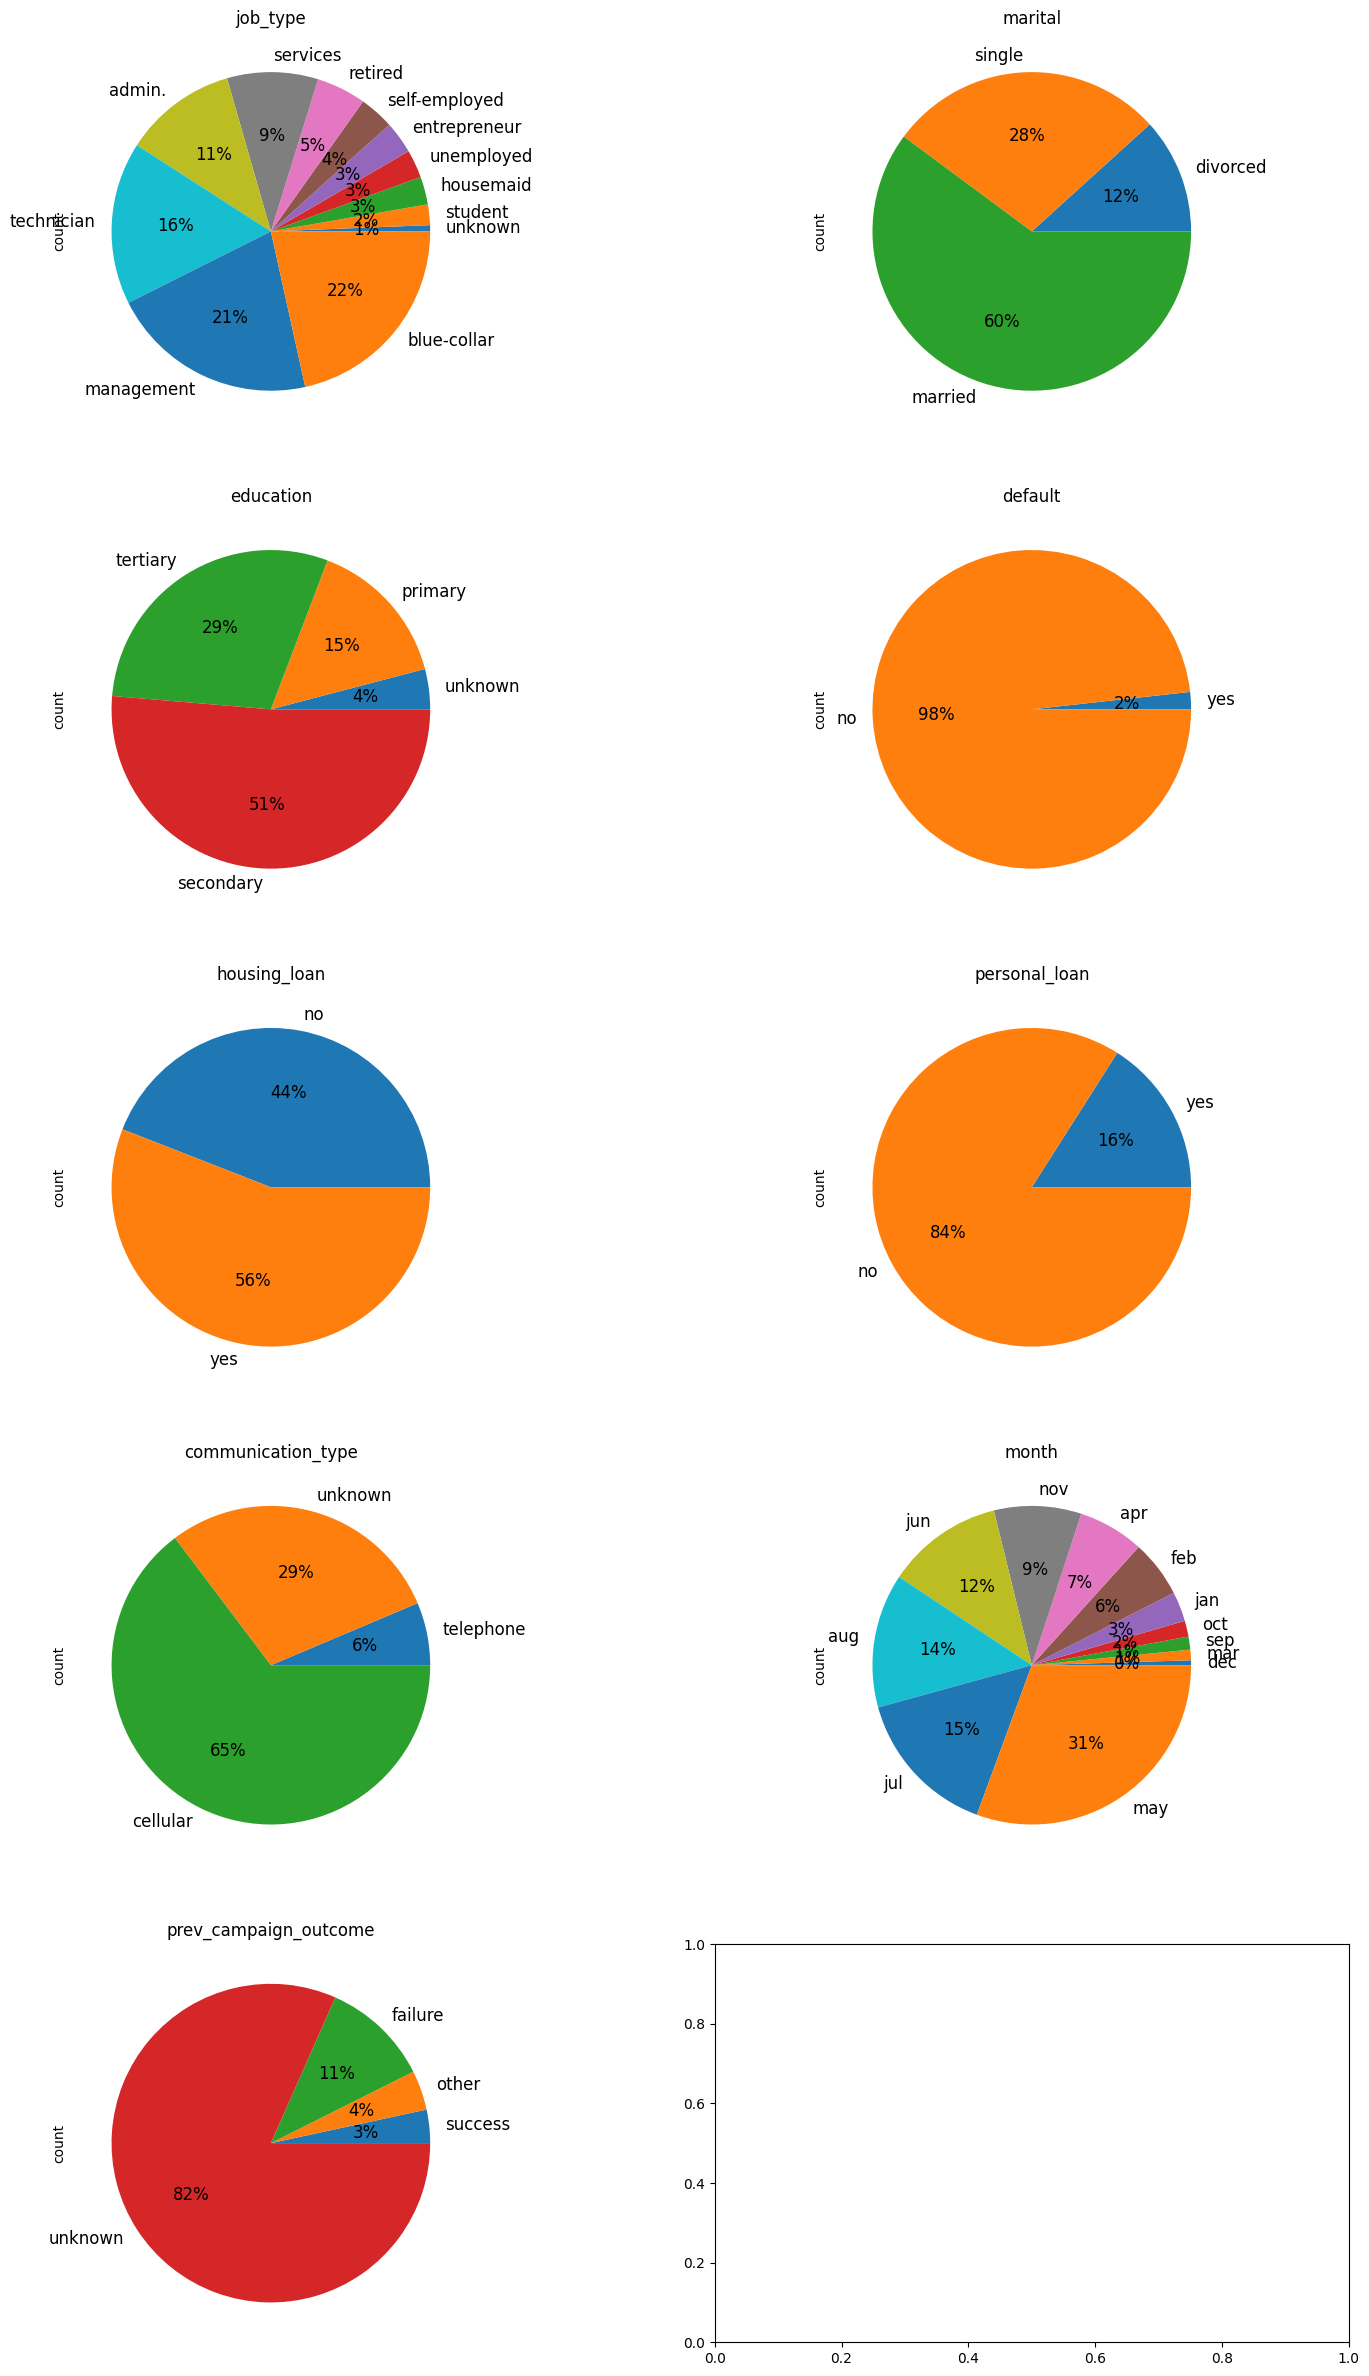

In [ ]:
fig , axes = plt.subplots(5 , 2 , figsize=(18 , 30))
axes = [ax for axes_rows in axes for ax in axes_rows]
# We create a grid of plots with 5 rows and 2 columns (10 plots total).
# Since axes is a 2D array, we flatten it into a single list so we can loop over it easily.
for i , col in enumerate(df[cat_cols]):
    df[col].value_counts()[::-1].plot(kind = 'pie' , ax =axes[i] , title =col ,autopct = "%.0f%%" ,  fontsize=12)

# This pie chart shows the percentage distribution of each category inside a column.
# value_counts() counts how many times each category appears.
# autopct="%.0f%%" shows percentages without decimals.
# Pie charts are useful to understand proportions.

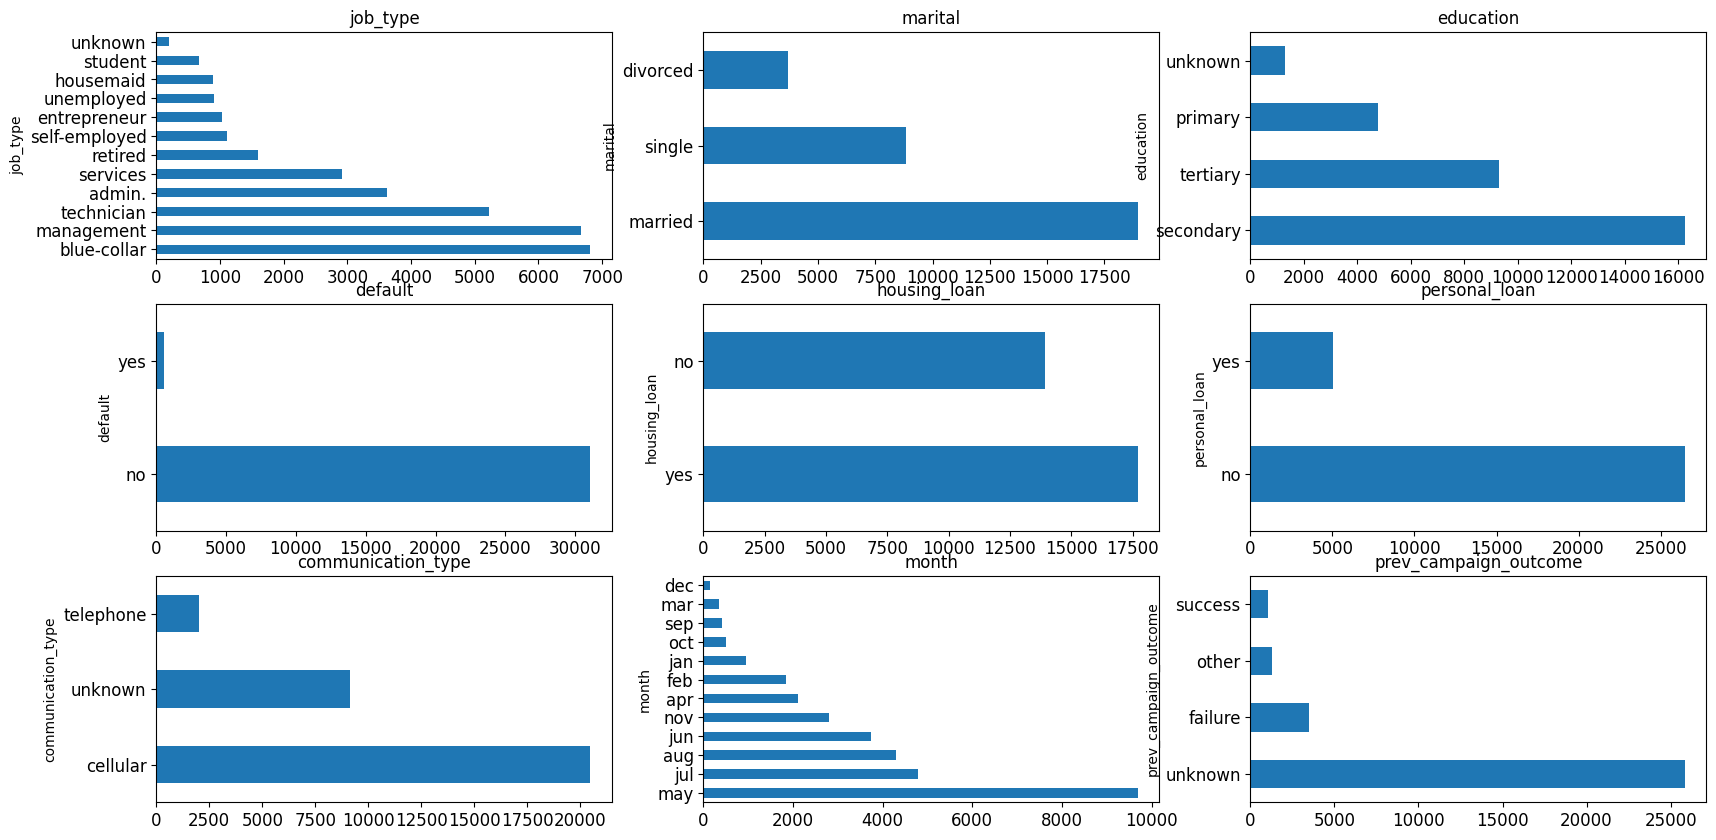

In [ ]:
fig , axes = plt.subplots(3 , 3 , figsize=(20 , 10))

axes = [ax for axes_rows in axes for ax in axes_rows]

for i , col in enumerate(df[cat_cols]):
  df[col].value_counts().plot(kind = 'barh' , ax =axes[i] , title =col ,fontsize=12)

# This horizontal bar chart shows counts instead of percentages.
# It is easier to compare categories when there are many values.

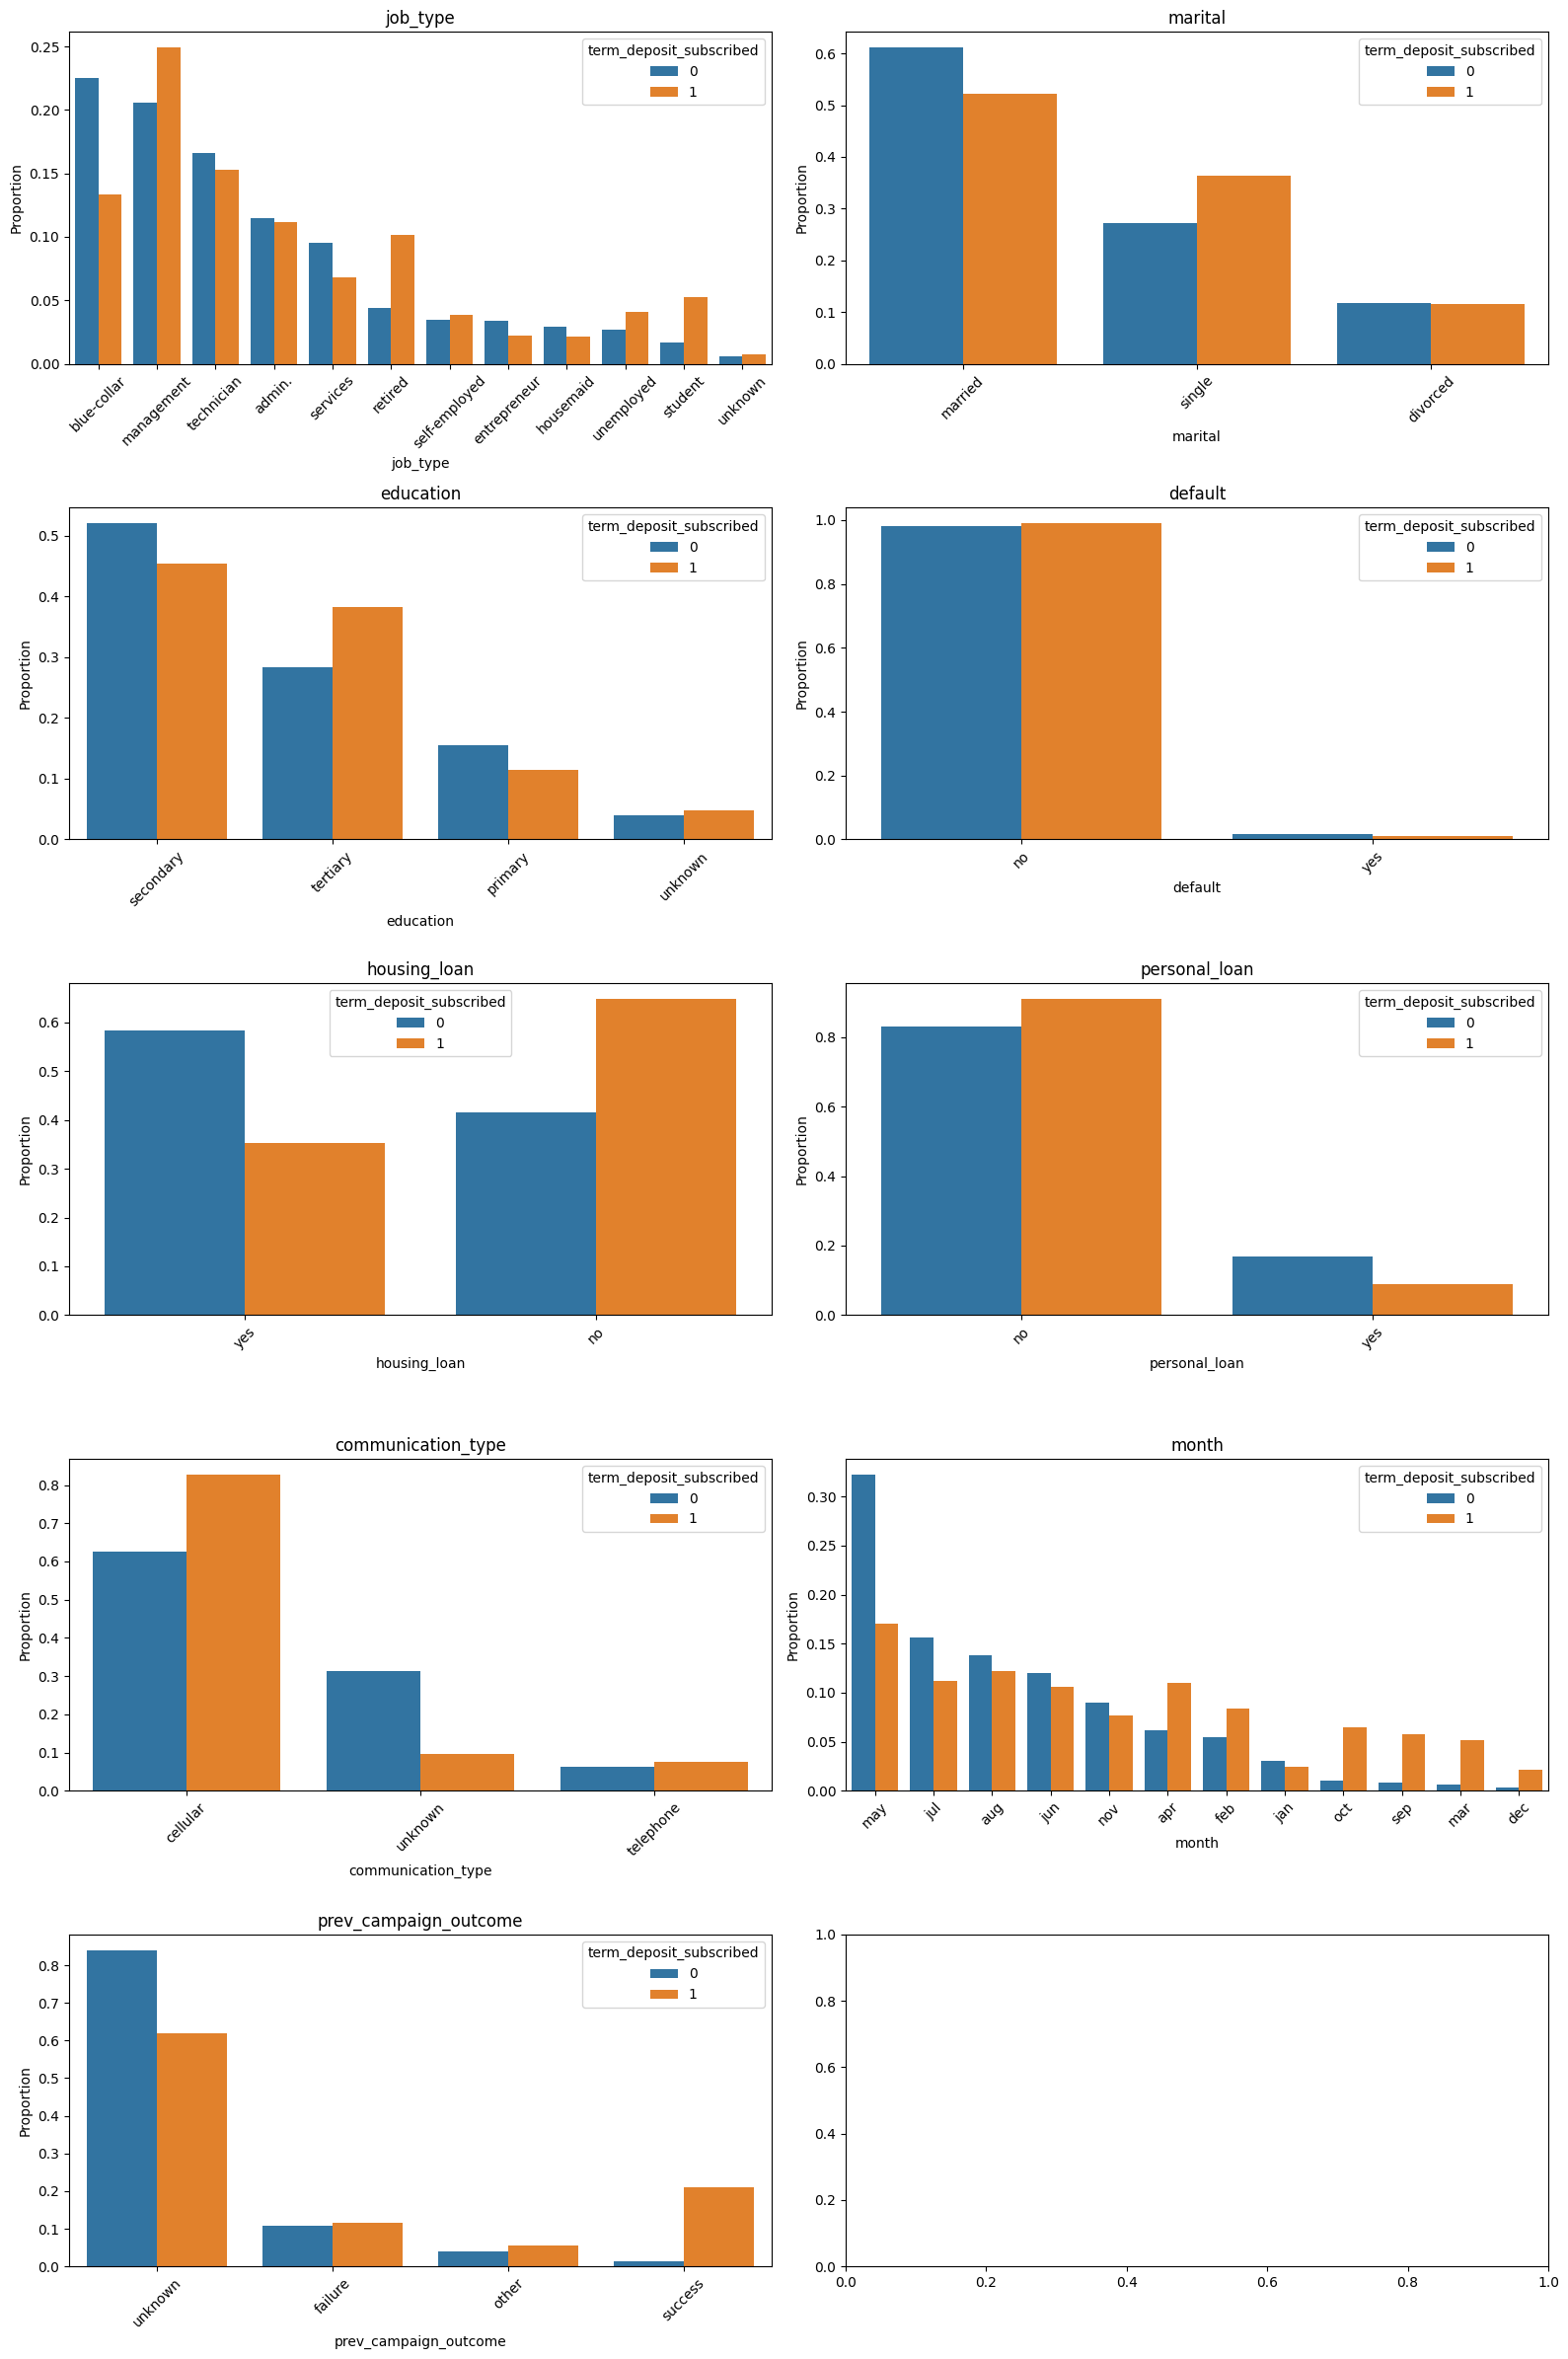

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

target_col = 'term_deposit_subscribed'

for i, column in enumerate(cat_cols):

    vc_a = (
        df[df[target_col] == 0][column]
        .value_counts(normalize=True)
        .rename('proportion')
        .reset_index()
        .rename(columns={'index': column})
    )
    # This calculates the percentage distribution of categories only for customers who did NOT subscribe.
    # normalize=True converts counts into proportions.
    # reset_index() makes the data usable for plotting.

    vc_b = (
        df[df[target_col] == 1][column]
        .value_counts(normalize=True)
        .rename('proportion')
        .reset_index()
        .rename(columns={'index': column})
    )
    # Same logic, but for customers who did subscribe.

    vc_a[target_col] = 0
    vc_b[target_col] = 1

    result = pd.concat([vc_a, vc_b], ignore_index=True) # This combines subscribers and non-subscribers into one table so we can compare them visually.

    sns.barplot(
        x=column,
        y='proportion',
        hue=target_col,
        data=result,
        ax=axes[i]
    )

    axes[i].set_title(column)
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel(column)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
features = [c for c in df.columns if c not in ['id' , 'term_deposit_subscribed']]
num_cols = [c for c in features if c not in cat_cols]
num_cols
# We remove ID and target columns.
# Then we remove categorical columns.
# What remains are numerical columns.

['customer_age',
 'balance',
 'day_of_month',
 'last_contact_duration',
 'num_contacts_in_campaign',
 'days_since_prev_campaign_contact',
 'num_contacts_prev_campaign']

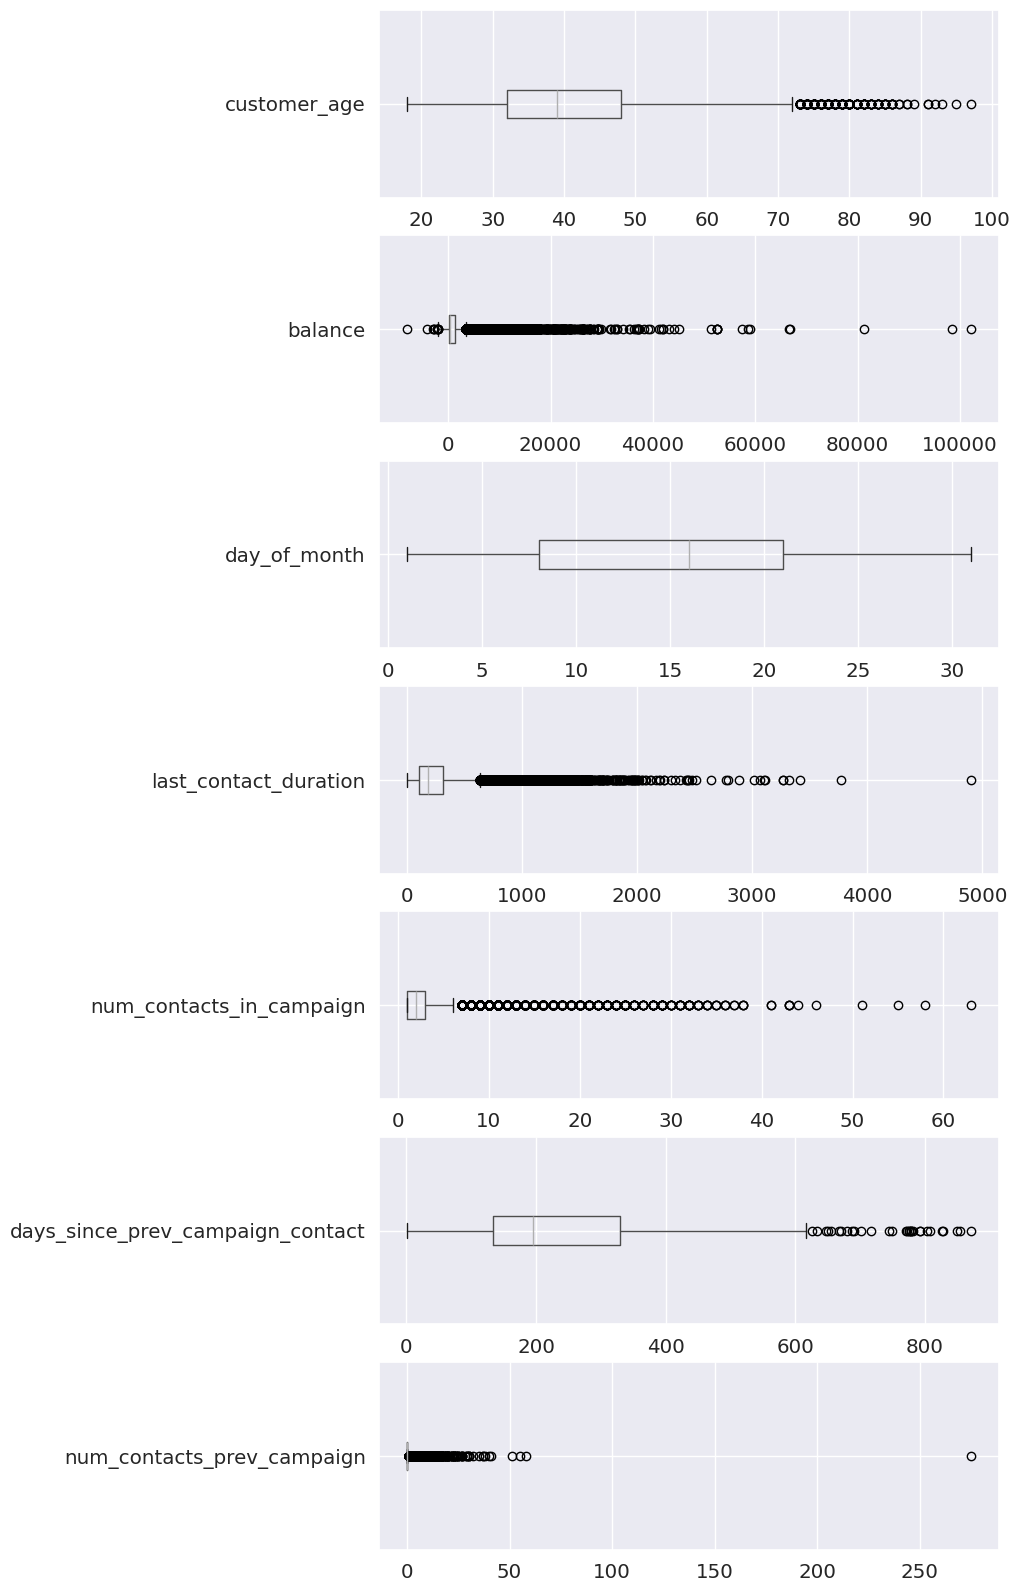

In [ ]:
# One-variable numerical analysis (Boxplot)
fig , axes = plt.subplots(7,1,figsize=(8,20))
for i , c in enumerate(num_cols):
  df[[c]].boxplot(ax =axes[i] , vert = False)

# Boxplots show:
# Median , Spread , Outliers
# vert=False makes it horizontal.
# ✅ Why boxplot?
# Detect outliers
# See data spread

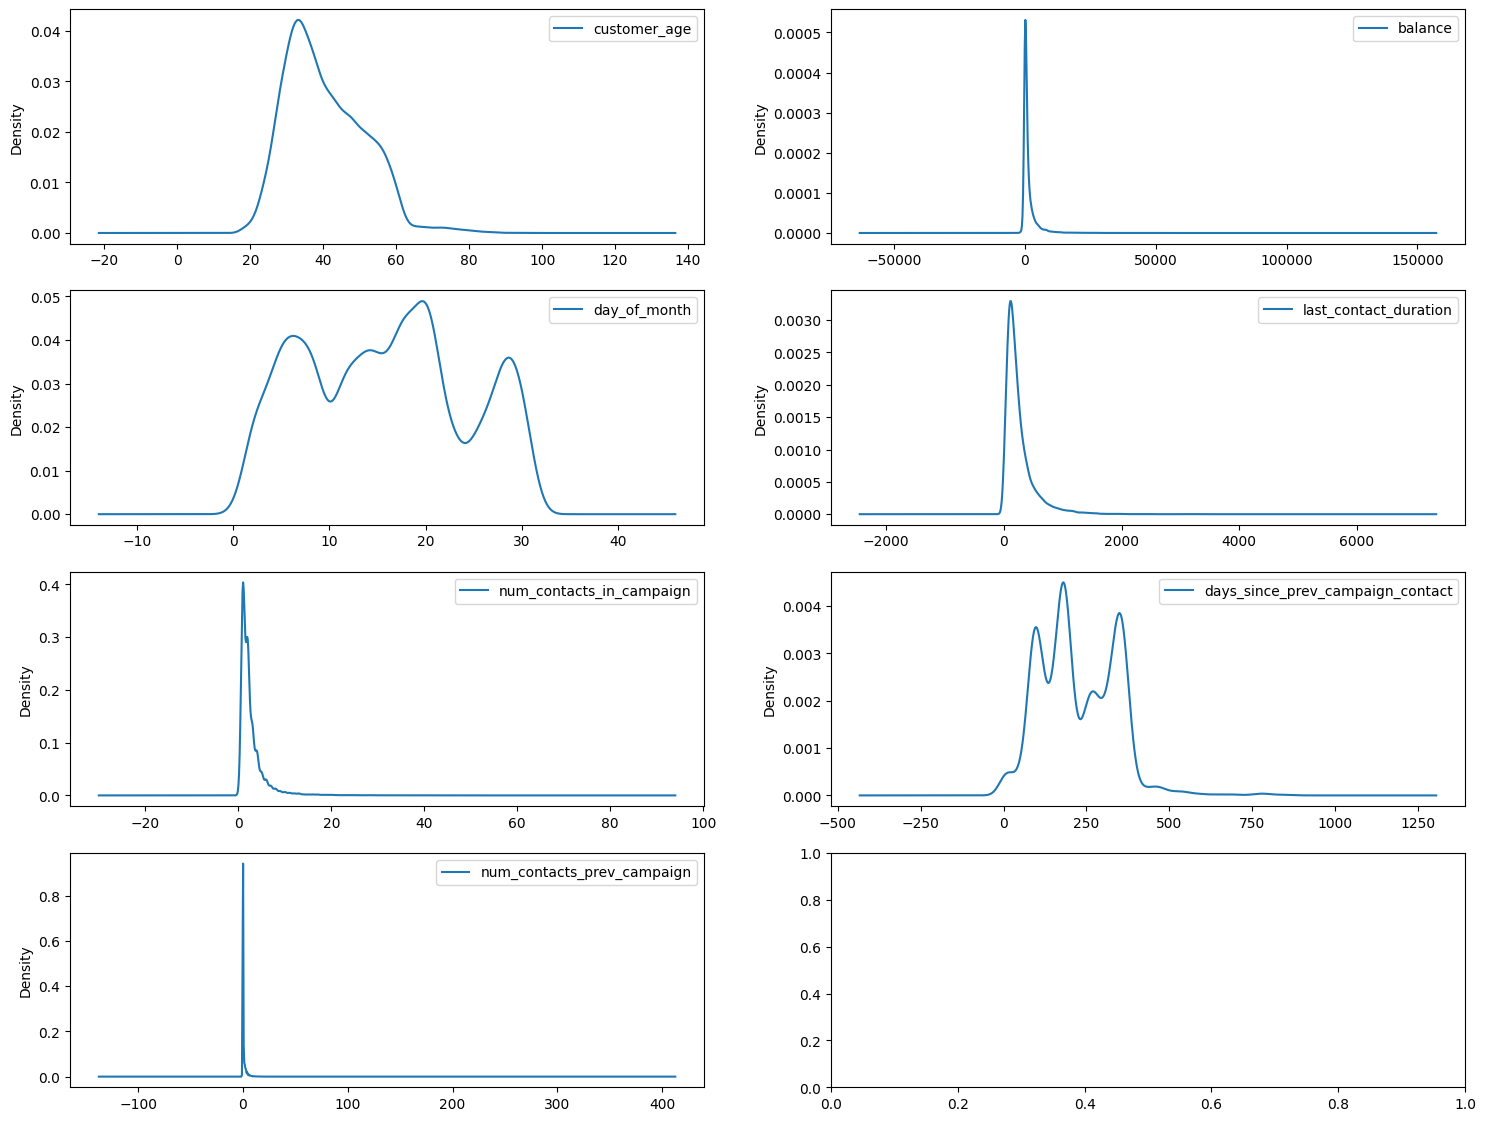

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(18,14))
axes = [ax for axes_rows in axes for ax in axes_rows]

for i, c in enumerate(num_cols):
    plot = df[[c]].plot(kind='kde', ax=axes[i])


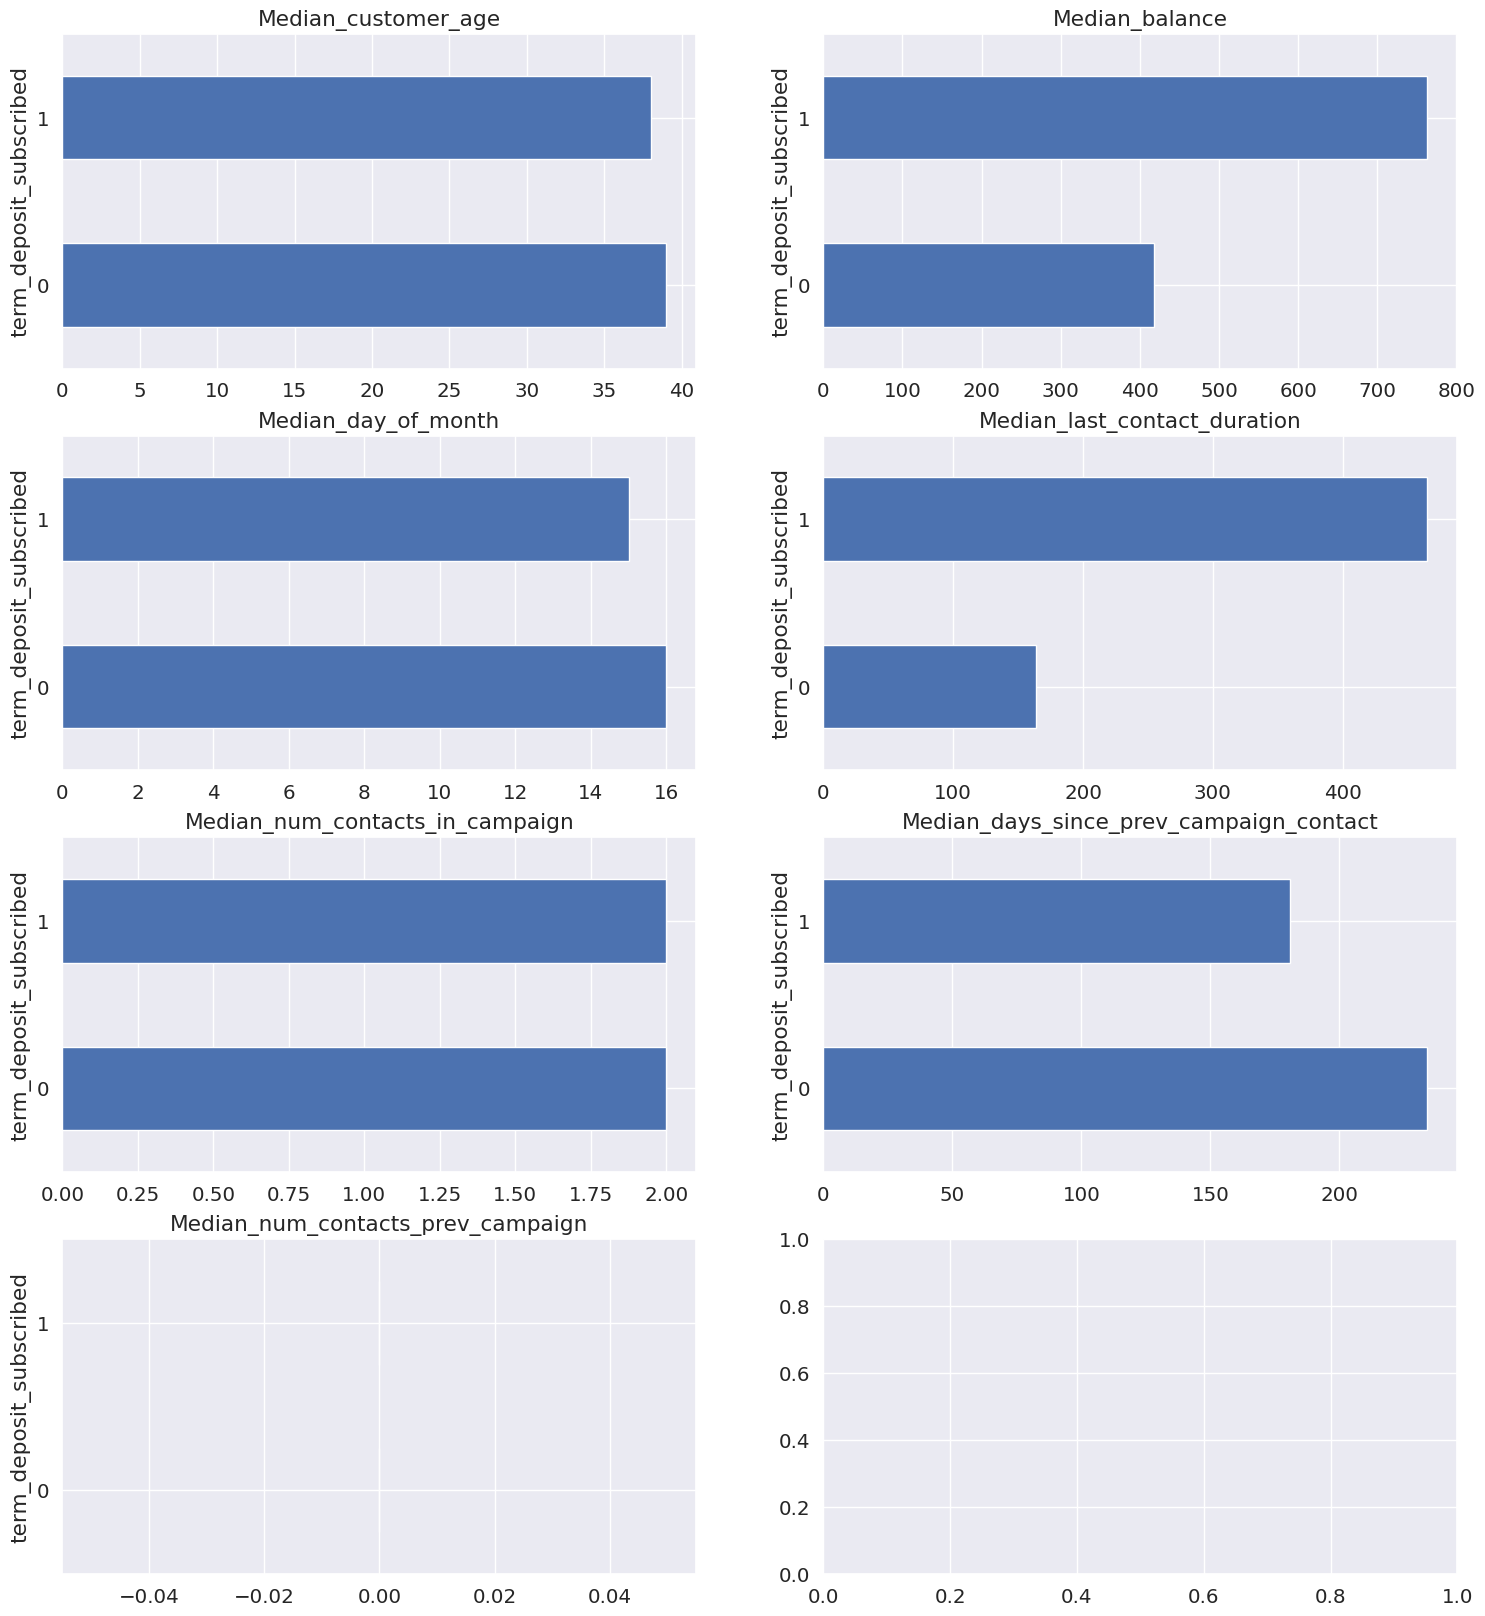

In [ ]:
sns.set(font_scale = 1.3)

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = [ax for axes_row in axes for ax in axes_row]

for i, c in enumerate(num_cols):
    df.groupby(target_col)[c].median().plot(kind = 'barh', title=f'Median_{c}', ax=axes[i])

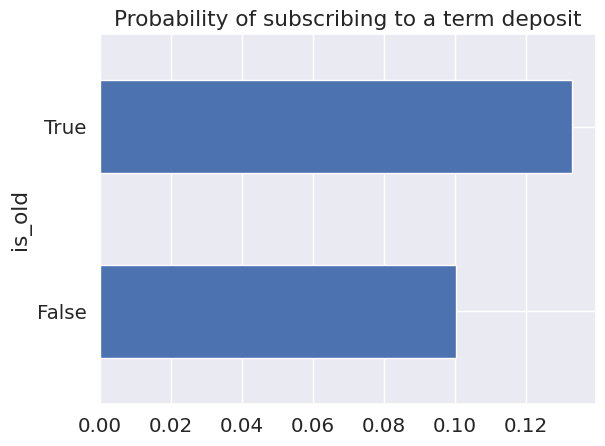

In [ ]:
df['is_old'] = True

df.loc[df['customer_age'] <= 50, 'is_old'] = False

_ = df.groupby('is_old')[target_col].mean().sort_values().plot(kind = 'barh', title='Probability of subscribing to a term deposit')
# The mean of the target represents probability.
# This shows whether older or younger customers are more likely to subscribe.